In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the dataset
housing = pd.read_csv("Housing.csv")

# Step 2: Inspect the data
print("--- Dataset Head ---")
print(housing.head())

print("\n--- Data Information ---")
housing.info()

print("\n--- Statistical Summary ---")
print(housing.describe())

--- Dataset Head ---
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 

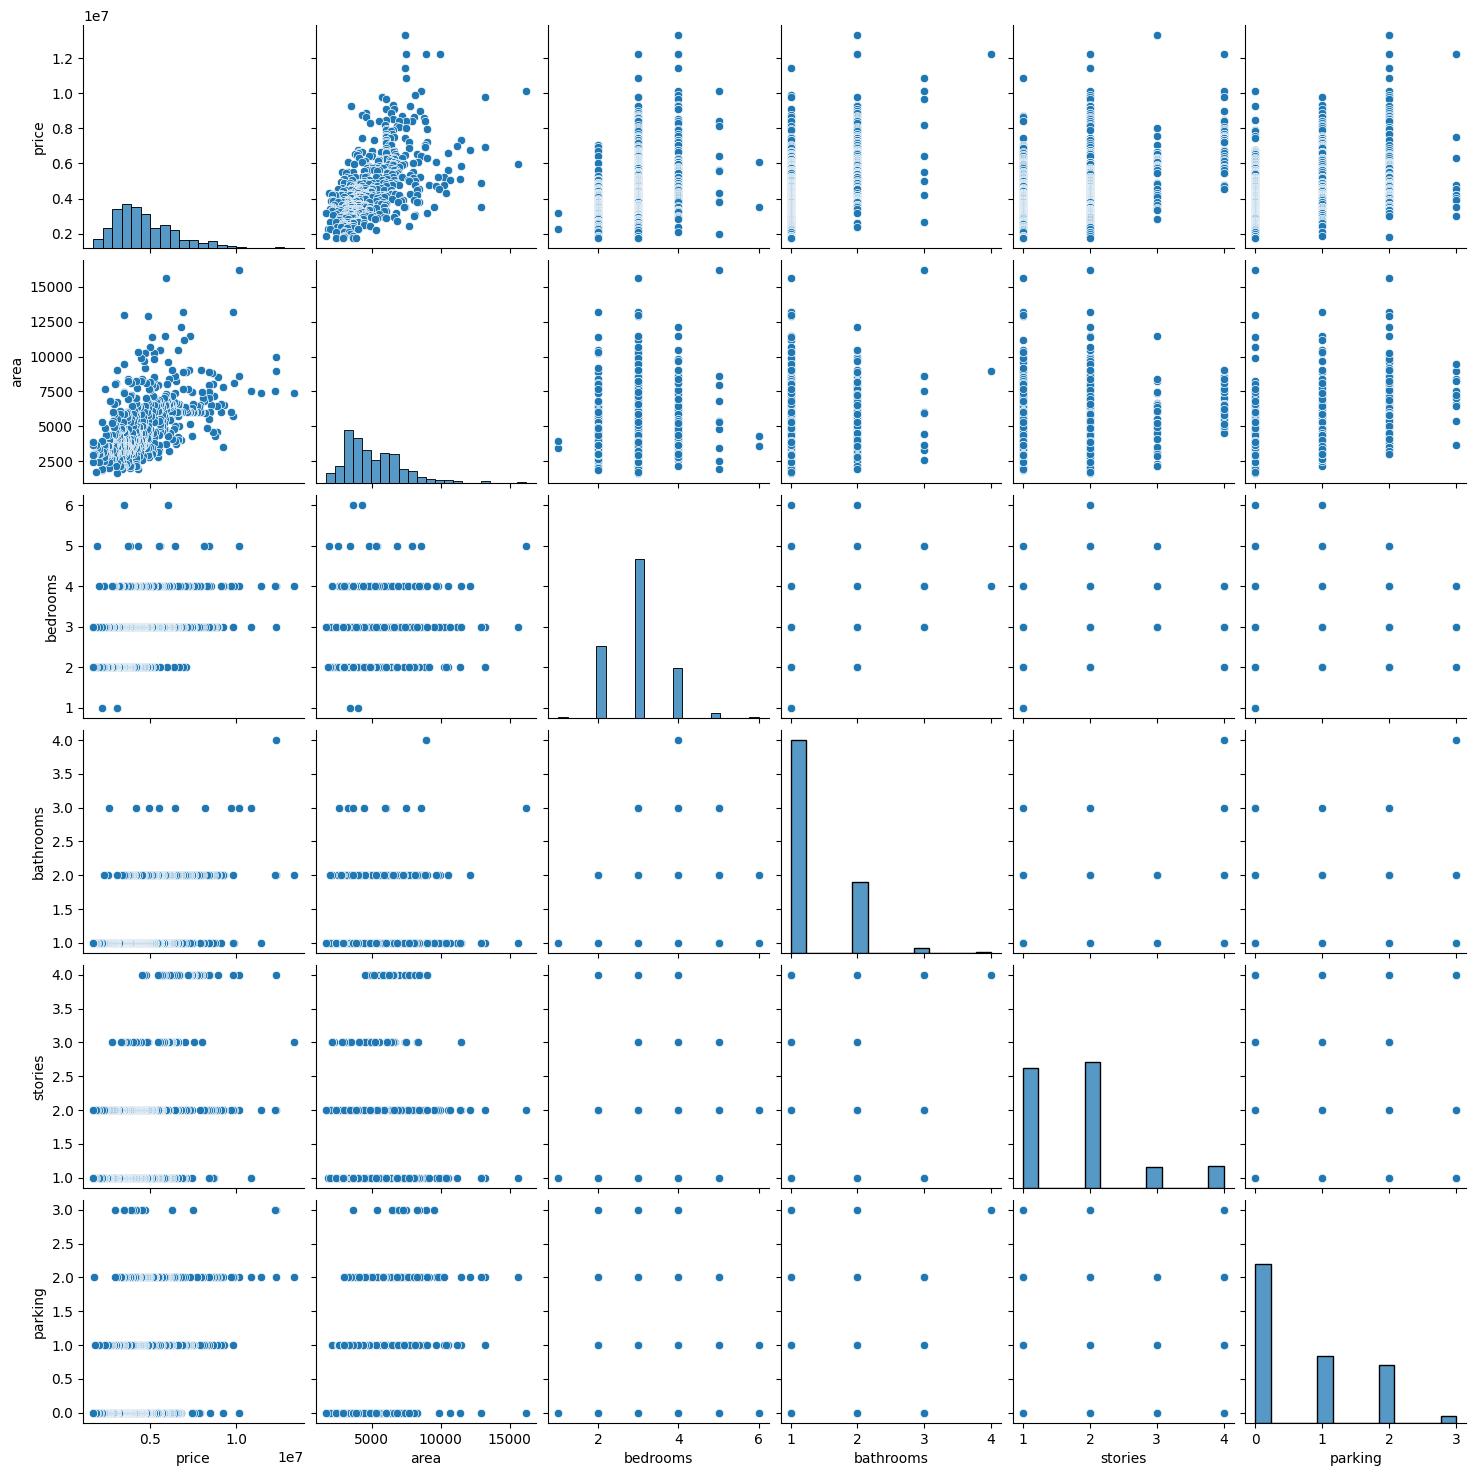

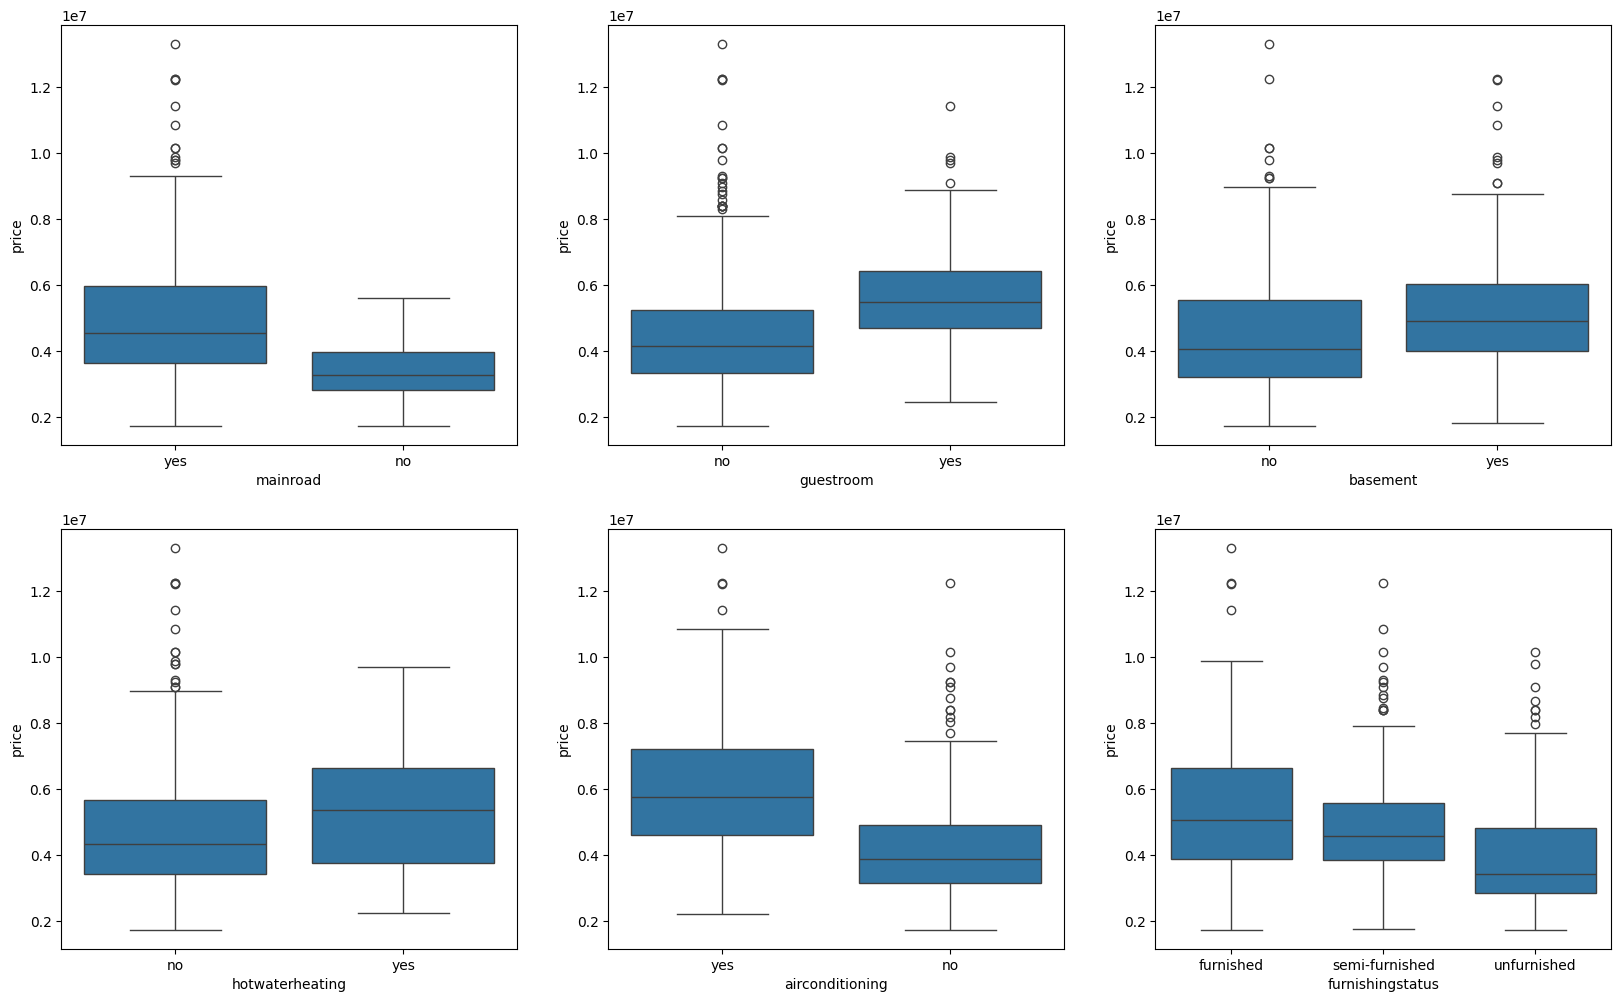

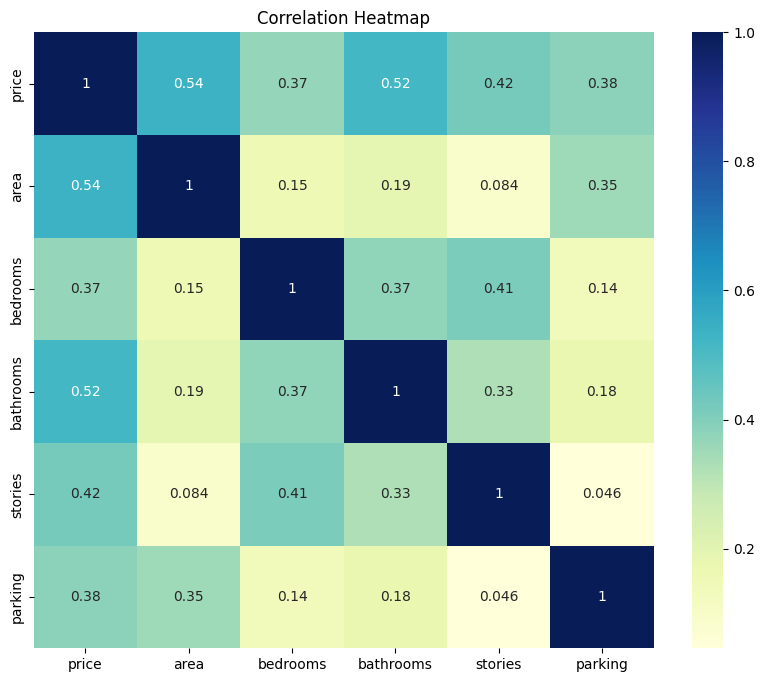

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualising Numerical Variables using Pairplot
# This shows the relationship between all numeric columns (Area, Bedrooms, etc.)
sns.pairplot(housing)
plt.show()

# 2. Visualising Categorical Variables using Boxplots
# This helps see how 'yes/no' features affect the price distribution
plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'mainroad', y = 'price', data = housing)
plt.subplot(2,3,2)
sns.boxplot(x = 'guestroom', y = 'price', data = housing)
plt.subplot(2,3,3)
sns.boxplot(x = 'basement', y = 'price', data = housing)
plt.subplot(2,3,4)
sns.boxplot(x = 'hotwaterheating', y = 'price', data = housing)
plt.subplot(2,3,5)
sns.boxplot(x = 'airconditioning', y = 'price', data = housing)
plt.subplot(2,3,6)
sns.boxplot(x = 'furnishingstatus', y = 'price', data = housing)
plt.show()

# 3. Correlation Heatmap (Numeric Only)
# We specify numeric_only=True to prevent the ValueError
plt.figure(figsize=(10, 8))
sns.heatmap(housing.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

In [4]:
# 1. Defining the list of variables to map to 0 and 1
varlist =  ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# 2. Defining the map function to convert yes/no
def binary_map(x):
    return x.map({'yes': 1, "no": 0})

# 3. Applying the function to the housing list
housing[varlist] = housing[varlist].apply(binary_map)

# 4. Creating dummy variables for 'furnishingstatus'
# This creates new columns for 'semi-furnished' and 'unfurnished'
status = pd.get_dummies(housing['furnishingstatus'], drop_first = True)

# 5. Add the results to the original housing dataframe
housing = pd.concat([housing, status], axis = 1)

# 6. Drop 'furnishingstatus' as we have created the dummies
housing.drop(['furnishingstatus'], axis = 1, inplace = True)

# Let's see the result
print("--- Data Encoding Complete ---")
housing.head()

--- Data Encoding Complete ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Splitting the Data into Training and Testing Sets
# We use a 70-30 split (70% for training, 30% for testing)
df_train, df_test = train_test_split(housing, train_size = 0.7, test_size = 0.3, random_state = 100)

# 2. Rescaling the Features using Min-Max Scaling
# Scaling ensures that 'area' (thousands) doesn't outweigh 'bedrooms' (single digits)
scaler = MinMaxScaler()

# Apply scaler to all columns except the dummy variables (which are already 0/1)
num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

print("--- Scaling Complete (Training Set) ---")
df_train.head()

--- Scaling Complete (Training Set) ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
359,0.169697,0.155227,0.4,0.0,0.000000,1,0,0,0,0,0.333333,0,False,True
19,0.615152,0.403379,0.4,0.5,0.333333,1,0,0,0,1,0.333333,1,True,False
159,0.321212,0.115628,0.4,0.5,0.000000,1,1,1,0,1,0.000000,0,False,False
35,0.548133,0.454417,0.4,0.5,1.000000,1,0,0,0,1,0.666667,0,False,False
28,0.575758,0.538015,0.8,0.5,0.333333,1,0,1,1,0,0.666667,0,False,True


In [6]:
from sklearn.linear_model import LinearRegression

# 1. Divide the training set into X and y
# y_train contains the 'price' (the target)
# X_train contains all other features (the predictors)
y_train = df_train.pop('price')
X_train = df_train

# 2. Initialize the Linear Regression model
lm = LinearRegression()

# 3. Fit the model to the training data
# This is where the model "learns" the coefficients for each feature
lm.fit(X_train, y_train)

# 4. Print the coefficients and intercept
print("Model Training Complete.")
print(f"Intercept: {lm.intercept_}")
print("\n--- Coefficients ---")
coeff_df = pd.DataFrame(lm.coef_, X_train.columns, columns=['Coefficient'])
print(coeff_df)

Model Training Complete.
Intercept: 0.02003284229638136

--- Coefficients ---
                 Coefficient
area                0.234664
bedrooms            0.046735
bathrooms           0.190823
stories             0.108516
mainroad            0.050441
guestroom           0.030428
basement            0.021595
hotwaterheating     0.084863
airconditioning     0.066881
parking             0.060735
prefarea            0.059428
semi-furnished      0.000921
unfurnished        -0.031006


R-squared Score: 0.6729582743459919


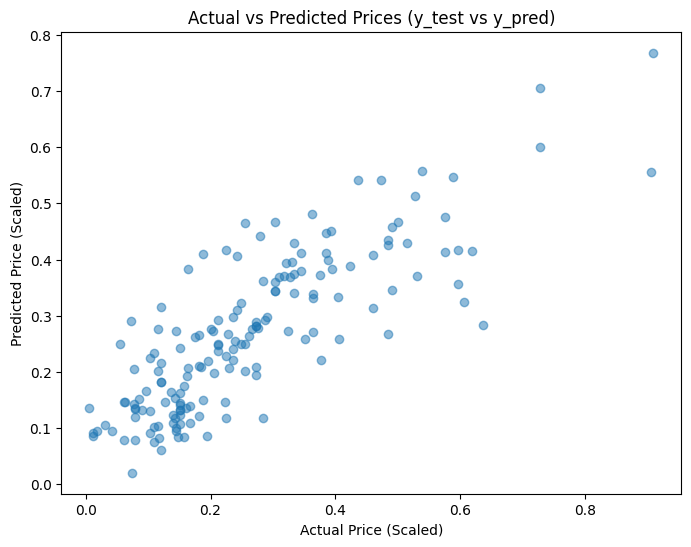

In [7]:
from sklearn.metrics import r2_score

# 1. Prepare the test data
# We must scale the test set using the SAME scaler we used for training
num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']
df_test[num_vars] = scaler.transform(df_test[num_vars])

# 2. Divide test set into X and y
y_test = df_test.pop('price')
X_test = df_test

# 3. Making predictions using the model
y_pred = lm.predict(X_test)

# 4. Evaluating the model
# Calculating the R-squared score
r_squared = r2_score(y_test, y_pred)

print(f"R-squared Score: {r_squared}")

# 5. Visualizing the results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Actual vs Predicted Prices (y_test vs y_pred)')
plt.xlabel('Actual Price (Scaled)')
plt.ylabel('Predicted Price (Scaled)')
plt.show()

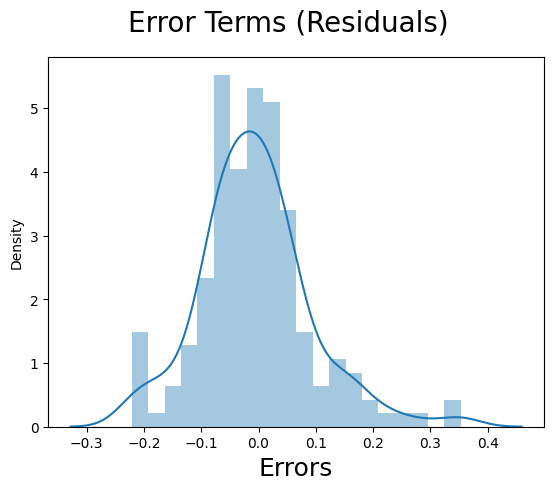

Final Mean Squared Error: 0.009624780513466765
Project 5 successfully completed.


In [8]:
from sklearn.metrics import mean_squared_error

# 1. Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# 2. Residual Analysis
# Plotting the histogram of the error terms
fig = plt.figure()
sns.distplot((y_test - y_pred), bins = 20)
fig.suptitle('Error Terms (Residuals)', fontsize = 20)
plt.xlabel('Errors', fontsize = 18)
plt.show()

print(f"Final Mean Squared Error: {mse}")
print("Project 5 successfully completed.")